# Text Preprocessing — ABSA Ulasan Hotel
Tahapan text preprocessing dilakukan pada kolom `review_text_translated`.

**Tahapan:**
1. Load Dataset Berlabel
2. WordCloud Awal (sebelum preprocessing)
3. Text Cleaning
4. Case Folding
5. Normalization (Frasa → Kamus Alay → Custom Dict → indoNLP)
6. Stopword Removal Tahap 1 — cek frekuensi kata
7. Stopword Removal Tahap 2 — tambah custom stopword
8. Stemming → hasilkan `review_non_stemmed` & `review_stemmed`
9. Export Dataset

---
**Input :** `hotel_reviews_labeled.xlsx`  
**Output:** `hotel_reviews_preprocessed.xlsx` & `hotel_reviews_for_modeling.csv`

## 1. Instalasi & Import Library

In [ ]:
!pip install PySastrawi indoNLP openpyxl xlsxwriter tqdm wordcloud --quiet

In [ ]:
import pandas as pd
import numpy as np
import re
import os
import warnings
from collections import Counter
from tqdm import tqdm
from google.colab import drive
import matplotlib.pyplot as plt
from wordcloud import WordCloud

from Sastrawi.Stemmer.StemmerFactory import StemmerFactory
from Sastrawi.StopWordRemover.StopWordRemoverFactory import StopWordRemoverFactory
import indoNLP.preprocessing as indoprep

warnings.filterwarnings('ignore')
tqdm.pandas()
pd.set_option('display.max_colwidth', 150)
pd.set_option('display.max_columns', None)

print("Library berhasil diimport.")

Library berhasil diimport.


## 2. Mount Google Drive & Konfigurasi

In [ ]:
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
INPUT_FILE  = '/content/drive/MyDrive/SKRIPSI_NAVY/Dataset/Dataset_Pelabelan/hotel_reviews_labeled.xlsx'
OUTPUT_DIR  = '/content/drive/MyDrive/SKRIPSI_NAVY/Dataset/Dataset_Persiapan/Dataset_Text_Preprocessing/'
OUTPUT_FILE = OUTPUT_DIR + 'hotel_reviews_preprocessed.xlsx'

TEXT_COL   = 'review_text_translated'
LABEL_COLS = ['Room', 'Hotel', 'Location', 'Service']

KAMUS_ALAY_URL = "https://raw.githubusercontent.com/okkyibrohim/id-multi-label-hate-speech-and-abusive-language-detection/master/new_kamusalay.csv"

os.makedirs(OUTPUT_DIR, exist_ok=True)
print("Konfigurasi selesai")

Konfigurasi selesai


## 3. Load Dataset

In [ ]:
df = pd.read_excel(INPUT_FILE, keep_default_na=False)
print(f"Dataset loaded: {df.shape[0]:,} baris, {df.shape[1]} kolom")
print(f"Kolom: {df.columns.tolist()}")

# Pastikan kolom teks tidak kosong
df[TEXT_COL] = df[TEXT_COL].fillna('').astype(str)

df[[TEXT_COL] + LABEL_COLS].head(10)

Dataset loaded: 7,821 baris, 17 kolom
Kolom: ['id', 'review_text', 'review_rating', 'review_date', 'url', 'username', 'hotel_name', 'city', 'hotel_rating', 'region', 'language', 'detected_language', 'review_text_translated', 'Room', 'Hotel', 'Location', 'Service']


,review_text_translated,Room,Hotel,Location,Service
0,"Pertama kali disini super kagum sama interior hotel <3\nauthentic banget kamarnya, nyaman dan TV nya besar banget.",Positive,Positive,None,None
1,"Pelayanan oke banget dibantu dengan resepsionis yang sangat ramah sekali, pelayanan memuaskan",None,None,None,Positive
2,Kolam renang dan gym nya sangat bagus dan yang terbaik dari hotel lain.,None,Positive,None,None
3,"Kami Sekeluarga senang. Kamarnya bersih dan nyaman. Area taman nya sangat rapi dan indah, kolam renang juga bagus",Positive,Positive,None,None
4,"Perbotan kamar seperti AC dan dispenser air minum sering kali tidak berfungsi, sangat mengganggu kenyamanan.",Negative,None,None,None
5,Dekorasinya sangat bagus tentang sejarah. Apalagi ada lukisan bersejarah.,None,Positive,None,None
6,"Staf sangat ramah dan mengajak kami berkeliling hotel, menceritakan sejarah, dan membantu mengambil foto.",None,None,None,Positive
7,staf didominasi oleh anak magang mengakibatkan pelayanan jadi tidak konsisten dan tidak profesional.,None,None,None,Negative
8,pelayanannya top dan pegawainya ramah sekali,None,None,None,Positive
9,"Pelayanan buruk, saya dibiarkan menurunkan barang dari mobil sendiri padahal ada staf yang melihat.",None,None,None,Negative


## 4. WordCloud & Menampilkan Contoh

Fungsi pembantu yang akan dipakai berulang di setiap tahapan.

In [ ]:
def tampil_wordcloud(series, judul, warna='Blues', simpan_path=None):
    """Buat dan tampilkan WordCloud dari seri teks."""
    gabung = ' '.join(series.dropna().astype(str).tolist())
    if len(gabung.strip()) < 10:
        print(f"[!] Tidak cukup teks untuk WordCloud: {judul}")
        return
    wc = WordCloud(
        width=900, height=450, background_color='white',
        max_words=100, collocations=False
    ).generate(gabung)
    fig, ax = plt.subplots(figsize=(12, 5))
    ax.imshow(wc, interpolation='bilinear')
    ax.set_title(judul, fontsize=14, fontweight='bold', pad=12)
    ax.axis('off')
    plt.tight_layout()
    if simpan_path:
        plt.savefig(simpan_path, dpi=150, bbox_inches='tight')
        print(f"WordCloud disimpan: {simpan_path}")
    plt.show()
    plt.close()


def tampil_contoh(df, col_sebelum, col_sesudah, judul_tahap, n=5):
    """Tampilkan perbandingan teks yang MENGALAMI PERUBAHAN saja."""
    print(f"\nContoh Hasil: {judul_tahap}")

    # Filter hanya baris yang teksnya berubah
    mask_berubah = df[col_sebelum].astype(str) != df[col_sesudah].astype(str)
    df_berubah = df[mask_berubah].head(n)[[col_sebelum, col_sesudah]].copy()

    if len(df_berubah) == 0:
        print("  Tidak ada perubahan yang terdeteksi.")
        return

    print(f"  ({mask_berubah.sum()} ulasan mengalami perubahan dari {len(df)} total)\n")

    df_berubah.index = [f"#{i+1}" for i in range(len(df_berubah))]
    df_berubah.columns = [f'Sebelum ({col_sebelum})', f'Sesudah ({col_sesudah})']

    for col in df_berubah.columns:
        df_berubah[col] = df_berubah[col].astype(str).apply(
            lambda x: x[:200] + '...' if len(x) > 200 else x
        )

    display(df_berubah)


def top_kata(series, n=100, judul=''):
    """Tampilkan n kata dengan frekuensi tertinggi."""
    semua = ' '.join(series.dropna().astype(str)).split()
    counter = Counter(semua)
    df_freq = pd.DataFrame(counter.most_common(n), columns=['Kata', 'Frekuensi'])
    if judul:
        print(f"\nTop {n} kata — {judul}:")
    return df_freq


print("Fungsi helper siap.")

Fungsi helper siap.


## 5. WordCloud Awal (Sebelum Preprocessing)

WordCloud disimpan: /content/drive/MyDrive/SKRIPSI_NAVY/Dataset/Dataset_Persiapan/Dataset_Text_Preprocessing/wc_00_awal.png


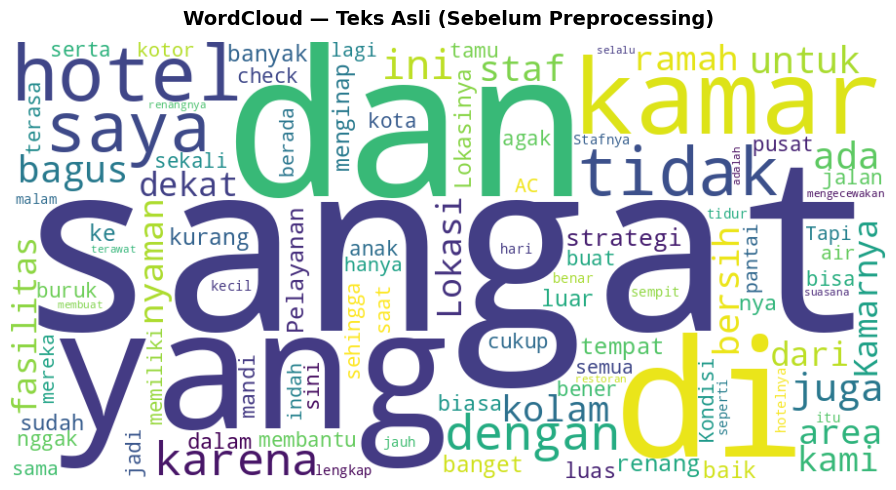

In [ ]:
tampil_wordcloud(
    df[TEXT_COL],
    'WordCloud — Teks Asli (Sebelum Preprocessing)',
    simpan_path=OUTPUT_DIR + 'wc_00_awal.png'
)

## 6. Text Cleaning

Membersihkan teks dari elemen yang tidak memiliki makna analisis sentimen.

**Urutan proses:**
1. Tambah spasi sebelum tanda baca — mencegah dua kata tergabung saat tanda baca dihapus (contoh: `hotel.Kamar` → `hotel Kamar`)
2. Hapus URL
3. Hapus HTML tags
4. Hapus emotikon & karakter non-ASCII
5. Hapus angka
6. Hapus tanda baca, kurung, petik, karakter khusus
7. Hapus spasi berlebih

In [ ]:
def text_cleaning(text):
    if not isinstance(text, str) or text.strip() == '':
        return ''
    # 1. Tambah spasi sebelum tanda baca agar kata tidak tergabung
    text = re.sub(r'([.!?,;:])', r' \1 ', text)
    # 2. Hapus URL
    text = indoprep.remove_url(text)
    # 3. Hapus HTML tags
    text = re.sub(r'<[^>]+>', ' ', text)
    # 4. Hapus emotikon & karakter non-ASCII
    text = text.encode('ascii', 'ignore').decode('ascii')
    # 5. Hapus angka
    text = re.sub(r'\d+', ' ', text)
    # 6. Hapus tanda baca & karakter khusus, pertahankan huruf dan spasi
    text = re.sub(r'[^a-zA-Z\s]', ' ', text)
    # 7. Hapus spasi berlebih
    text = re.sub(r'\s+', ' ', text).strip()
    return text

print("Proses Text Cleaning")
df['review_clean'] = df[TEXT_COL].progress_apply(text_cleaning)

Proses Text Cleaning


100%|██████████| 7821/7821 [00:00<00:00, 10498.54it/s]


In [ ]:
tampil_contoh(df, TEXT_COL, 'review_clean', 'Text Cleaning', n=10)


Contoh Hasil: Text Cleaning
  (7746 ulasan mengalami perubahan dari 7821 total)



,Sebelum (review_text_translated),Sesudah (review_clean)
#1,"Pertama kali disini super kagum sama interior hotel <3\nauthentic banget kamarnya, nyaman dan TV nya besar banget.",Pertama kali disini super kagum sama interior hotel authentic banget kamarnya nyaman dan TV nya besar banget
#2,"Pelayanan oke banget dibantu dengan resepsionis yang sangat ramah sekali, pelayanan memuaskan",Pelayanan oke banget dibantu dengan resepsionis yang sangat ramah sekali pelayanan memuaskan
#3,Kolam renang dan gym nya sangat bagus dan yang terbaik dari hotel lain.,Kolam renang dan gym nya sangat bagus dan yang terbaik dari hotel lain
#4,"Kami Sekeluarga senang. Kamarnya bersih dan nyaman. Area taman nya sangat rapi dan indah, kolam renang juga bagus",Kami Sekeluarga senang Kamarnya bersih dan nyaman Area taman nya sangat rapi dan indah kolam renang juga bagus
#5,"Perbotan kamar seperti AC dan dispenser air minum sering kali tidak berfungsi, sangat mengganggu kenyamanan.",Perbotan kamar seperti AC dan dispenser air minum sering kali tidak berfungsi sangat mengganggu kenyamanan
#6,Dekorasinya sangat bagus tentang sejarah. Apalagi ada lukisan bersejarah.,Dekorasinya sangat bagus tentang sejarah Apalagi ada lukisan bersejarah
#7,"Staf sangat ramah dan mengajak kami berkeliling hotel, menceritakan sejarah, dan membantu mengambil foto.",Staf sangat ramah dan mengajak kami berkeliling hotel menceritakan sejarah dan membantu mengambil foto
#8,staf didominasi oleh anak magang mengakibatkan pelayanan jadi tidak konsisten dan tidak profesional.,staf didominasi oleh anak magang mengakibatkan pelayanan jadi tidak konsisten dan tidak profesional
#9,"Pelayanan buruk, saya dibiarkan menurunkan barang dari mobil sendiri padahal ada staf yang melihat.",Pelayanan buruk saya dibiarkan menurunkan barang dari mobil sendiri padahal ada staf yang melihat
#10,Staffnya sangat membantu Dan Sabar menjelaskan. Hotel ini sangat nyaman dan dekorasinya bagus banget,Staffnya sangat membantu Dan Sabar menjelaskan Hotel ini sangat nyaman dan dekorasinya bagus banget


WordCloud disimpan: /content/drive/MyDrive/SKRIPSI_NAVY/Dataset/Dataset_Persiapan/Dataset_Text_Preprocessing/wc_01_cleaning.png


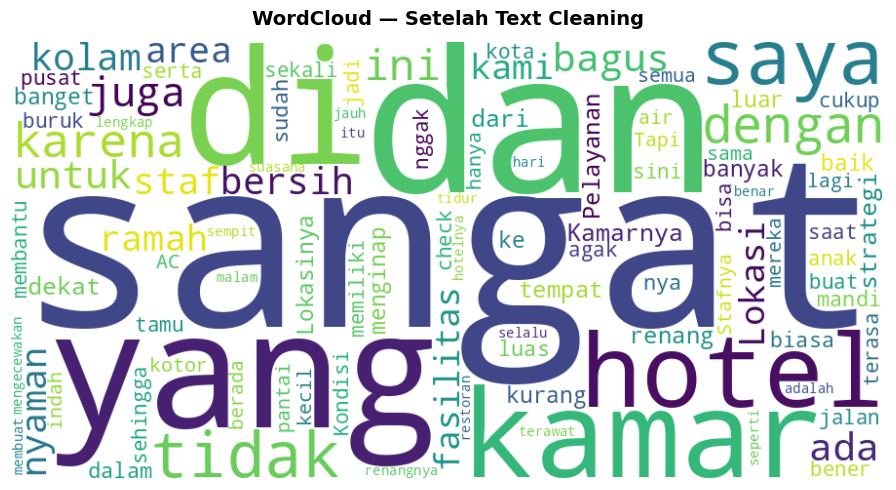

In [ ]:
tampil_wordcloud(
    df['review_clean'],
    'WordCloud — Setelah Text Cleaning',
    simpan_path=OUTPUT_DIR + 'wc_01_cleaning.png'
)

## 7. Case Folding

Mengubah seluruh teks menjadi huruf kecil agar `Hotel`, `hotel`, dan `HOTEL` diperlakukan sebagai kata yang sama.

In [ ]:
df['review_casefolded'] = df['review_clean'].str.lower()

tampil_contoh(df, 'review_clean', 'review_casefolded', 'Case Folding', n=10)


Contoh Hasil: Case Folding
  (7657 ulasan mengalami perubahan dari 7821 total)



,Sebelum (review_clean),Sesudah (review_casefolded)
#1,Pertama kali disini super kagum sama interior hotel authentic banget kamarnya nyaman dan TV nya besar banget,pertama kali disini super kagum sama interior hotel authentic banget kamarnya nyaman dan tv nya besar banget
#2,Pelayanan oke banget dibantu dengan resepsionis yang sangat ramah sekali pelayanan memuaskan,pelayanan oke banget dibantu dengan resepsionis yang sangat ramah sekali pelayanan memuaskan
#3,Kolam renang dan gym nya sangat bagus dan yang terbaik dari hotel lain,kolam renang dan gym nya sangat bagus dan yang terbaik dari hotel lain
#4,Kami Sekeluarga senang Kamarnya bersih dan nyaman Area taman nya sangat rapi dan indah kolam renang juga bagus,kami sekeluarga senang kamarnya bersih dan nyaman area taman nya sangat rapi dan indah kolam renang juga bagus
#5,Perbotan kamar seperti AC dan dispenser air minum sering kali tidak berfungsi sangat mengganggu kenyamanan,perbotan kamar seperti ac dan dispenser air minum sering kali tidak berfungsi sangat mengganggu kenyamanan
#6,Dekorasinya sangat bagus tentang sejarah Apalagi ada lukisan bersejarah,dekorasinya sangat bagus tentang sejarah apalagi ada lukisan bersejarah
#7,Staf sangat ramah dan mengajak kami berkeliling hotel menceritakan sejarah dan membantu mengambil foto,staf sangat ramah dan mengajak kami berkeliling hotel menceritakan sejarah dan membantu mengambil foto
#8,Pelayanan buruk saya dibiarkan menurunkan barang dari mobil sendiri padahal ada staf yang melihat,pelayanan buruk saya dibiarkan menurunkan barang dari mobil sendiri padahal ada staf yang melihat
#9,Staffnya sangat membantu Dan Sabar menjelaskan Hotel ini sangat nyaman dan dekorasinya bagus banget,staffnya sangat membantu dan sabar menjelaskan hotel ini sangat nyaman dan dekorasinya bagus banget
#10,Lokasinya bangus banget mau kemana saja dekat bisa jalan kaki kamarnya nyaman SUKA BANGET,lokasinya bangus banget mau kemana saja dekat bisa jalan kaki kamarnya nyaman suka banget


WordCloud disimpan: /content/drive/MyDrive/SKRIPSI_NAVY/Dataset/Dataset_Persiapan/Dataset_Text_Preprocessing/wc_02_casefolding.png


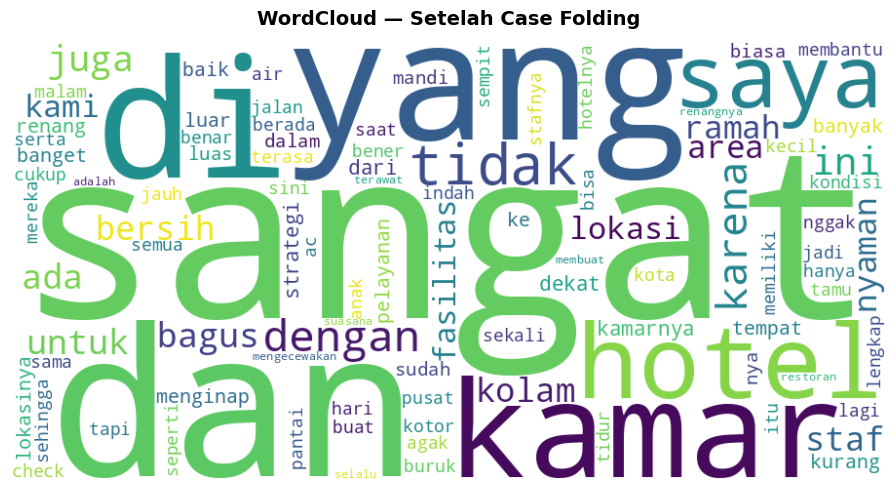

In [ ]:
tampil_wordcloud(
    df['review_casefolded'],
    'WordCloud — Setelah Case Folding',
    simpan_path=OUTPUT_DIR + 'wc_02_casefolding.png'
)

## 8. Normalization

Menstandarisasi kata tidak baku, singkatan, slang, dan frasa domain hotel.

**Urutan Normalisasi:**
1. **Frasa domain hotel** — menggabungkan frasa multi-kata agar tidak terpecah (`check in` → `checkin`, `swimming pool` → `kolam renang`)
2. **indoNLP `replace_word_elongation`** — normalisasi huruf berulang (`bagusssss` → `bagus`)
3. **Kamus Alay** (new_kamusalay.csv dari GitHub) — kamus kata tidak baku Bahasa Indonesia
4. **Custom normalization dict** — kata-kata spesifik yang tidak tercakup kamus alay

Proses preprocessing frasa dilakukan terlebih dahulu agar `check in` tidak terpecah menjadi `check` dan `in` yang kehilangan maknanya setelah tokenisasi.

In [ ]:
# Load Kamus Alay
print("Mengunduh kamus alay dari GitHub...")
kamusalay = pd.read_csv(
    KAMUS_ALAY_URL,
    encoding='latin-1',
    header=None
)
kamusalay.columns = ['slang', 'formal']

# Konversi ke dictionary (huruf kecil semua)
kamus_alay_dict = dict(zip(
    kamusalay['slang'].astype(str).str.lower().str.strip(),
    kamusalay['formal'].astype(str).str.lower().str.strip()
))

print(f"Kamus alay: {len(kamus_alay_dict):,} entri")

Mengunduh kamus alay dari GitHub...
Kamus alay: 15,167 entri


In [ ]:
# Frasa Domain Hotel
# Frasa multi-kata yang umum di ulasan hotel digabung agar tidak kehilangan makna
frasa_hotel = {
    # Operasional
    'check in'        : 'checkin',
    'check out'       : 'checkout',
    'cek in'          : 'checkin',
    'cek out'         : 'checkout',
    'early check in'  : 'earlycheckin',
    'late check out'  : 'latecheckout',
    # Fasilitas
    'air conditioner' : 'ac',
    'air conditioning': 'ac',
    'wi fi'           : 'wifi',
    # Nilai
    'worth it'        : 'worthit',
}

print(f"Frasa domain hotel: {len(frasa_hotel)} entri")

Frasa domain hotel: 10 entri


In [ ]:
# Custom Normalization Dictionary
custom_norm_dict = {
    # Negasi — dinormalisasi agar konsisten
    'nggak'     : 'tidak',
    'nggk'      : 'tidak',
    'ngga'      : 'tidak',
    'gak'       : 'tidak',
    'ga'        : 'tidak',
    'enggak'    : 'tidak',
    'ngak'      : 'tidak',
    'kagak'     : 'tidak',
    'tdk'       : 'tidak',
    'gaada'     : 'tidak ada',
    'gada'      : 'tidak ada',
    # Singkatan umum
    'bgt'       : 'banget',
    'dr'        : 'dari',
    'yg'        : 'yang',
    'jd'        : 'jadi',
    'utk'       : 'untuk',
    'byk'       : 'banyak',
    'krn'       : 'karena',
    'karna'     : 'karena',
    'krg'       : 'kurang',
    'jgn'       : 'jangan',
    'jngan'     : 'jangan',
    'lg'        : 'lagi',
    'aja'       : 'saja',
    'sja'       : 'saja',
    'hny'       : 'hanya',
    'dlm'       : 'dalam',
    'shngga'    : 'sehingga',
    'ckup'      : 'cukup',
    'plg'       : 'paling',
    'kmr'       : 'kamar',
    'mndi'      : 'mandi',
    'tuh'       : 'itu',
    'lo'        : 'kamu',
    'gue'       : 'saya',
    'gw'        : 'saya',
    'aq'        : 'saya',
    'sy'        : 'saya',
    'knp'       : 'kenapa',
    'knpnya'    : 'kenapa',
    'klo'       : 'kalau',
    'kl'       : 'kalau',
    'kalo'      : 'kalau',
    'ky'        : 'seperti',
    'kyk'        : 'seperti',
    'kayak'     : 'seperti',
    # Kata tidak baku / informal
    'pgn'       : 'ingin',
    'pengen'    : 'ingin',
    'pingin'    : 'ingin',
    'udah'      : 'sudah',
    'udh'       : 'sudah',
    'deket'     : 'dekat',
    'bener'     : 'benar',
    'pake'      : 'pakai',
    'cuman'     : 'hanya',
    'rame'      : 'ramai',
    'lelet'     : 'lambat',
    'sendal'    : 'sandal',
    'batrai'    : 'baterai',
    'remot'     : 'remote',
    'trimakasi' : 'terima kasih',
    'terimakasi': 'terima kasih',
    'makasi'    : 'terima kasih',
    'gara-gara' : 'karena',
    'ngerugiin' : 'merugikan',
    'dicuekin'  : 'diabaikan',
    'pokoknya'  : 'intinya',
    'tetep'     : 'tetap',
    'berasa'    : 'terasa',
    'ngerasa'   : 'merasa',
    'muter'     : 'berputar',
    'nemu'      : 'menemukan',
    'ilang'     : 'hilang',
    'nempel'    : 'menempel',
    'copot'     : 'lepas',
    'zonk'      : 'buruk',
    'becus'     : 'mampu',
    'mampet'    : 'tersumbat',
    'kesumbat'  : 'tersumbat',
    'nginep'    : 'menginap',
    'nginap'    : 'menginap',
    'asyik'     : 'menyenangkan',
    'balik'     : 'kembali',
    'rebutan'   : 'berebut',
    'gampang'   : 'mudah',
    'nggk'      : 'tidak',
}

print(f"Custom normalization dict: {len(custom_norm_dict)} entri")

Custom normalization dict: 85 entri


In [ ]:
# Cek kata mana yang sudah ada di kamus alay
kata_custom = list(custom_norm_dict.keys())
sudah_di_alay = {k: kamus_alay_dict[k] for k in kata_custom if k in kamus_alay_dict}
belum_di_alay = {k: v for k, v in custom_norm_dict.items() if k not in kamus_alay_dict}

print(f"Sudah ada di kamus alay ({len(sudah_di_alay)} kata) — pertimbangkan hapus dari custom dict:")
for k, v in sudah_di_alay.items():
    print(f"  '{k}' → alay: '{v}' | custom: '{custom_norm_dict[k]}'")

print(f"\nHanya ada di custom dict ({len(belum_di_alay)} kata) — ini yang perlu dipertahankan:")
for k, v in belum_di_alay.items():
    print(f"  '{k}' → '{v}'")

Sudah ada di kamus alay (65 kata) — pertimbangkan hapus dari custom dict:
  'nggak' → alay: 'enggak' | custom: 'tidak'
  'nggk' → alay: 'tidak' | custom: 'tidak'
  'ngga' → alay: 'tidak' | custom: 'tidak'
  'gak' → alay: 'tidak' | custom: 'tidak'
  'ga' → alay: 'tidak' | custom: 'tidak'
  'enggak' → alay: 'tidak' | custom: 'tidak'
  'ngak' → alay: 'tidak' | custom: 'tidak'
  'kagak' → alay: 'tidak' | custom: 'tidak'
  'tdk' → alay: 'tidak' | custom: 'tidak'
  'gaada' → alay: 'tidak ada' | custom: 'tidak ada'
  'gada' → alay: 'tidak ada' | custom: 'tidak ada'
  'bgt' → alay: 'banget' | custom: 'banget'
  'dr' → alay: 'dari' | custom: 'dari'
  'yg' → alay: 'yang' | custom: 'yang'
  'jd' → alay: 'jadi' | custom: 'jadi'
  'utk' → alay: 'untuk' | custom: 'untuk'
  'byk' → alay: 'banyak' | custom: 'banyak'
  'krn' → alay: 'karena' | custom: 'karena'
  'karna' → alay: 'karena' | custom: 'karena'
  'krg' → alay: 'kurang' | custom: 'kurang'
  'jgn' → alay: 'jangan' | custom: 'jangan'
  'jngan' 

In [ ]:
# Revisi Custom Normalization Dictionary
# Berisi kata-kata yang tidak ada di kamus alay, sekaligus mengoreksi kata dari kamus alay yang tidak sesuai konteks

custom_norm_dict = {
    # Koreksi hasil kamus alay yang tidak sesuai konteks
    'plg'       : 'paling',     # kamus alay → 'pulang', koreksi ke 'paling'
    'cuman'     : 'cuma',       # sesuaikan dengan kamus alay → 'cuma'
    'dicuekin'  : 'dicueki',    # sesuaikan dengan kamus alay → 'dicueki'

    # Negasi
    'nggak'  : 'tidak',

    # Hanya ada di custom dict (tidak ada di kamus alay)
    'shngga'    : 'sehingga',
    'gue'       : 'saya',
    'knpnya'    : 'kenapa',
    'kyk'       : 'seperti',
    'kayak'     : 'seperti',
    'ky'        : 'seperti',
    'lelet'     : 'lambat',
    'sendal'    : 'sandal',
    'batrai'    : 'baterai',
    'remot'     : 'remote',
    'trimakasi' : 'terima kasih',
    'berasa'    : 'terasa',
    'kesumbat'  : 'tersumbat',
    'nginap'    : 'menginap',
}

print(f"Custom normalization dict: {len(custom_norm_dict)} entri")

Custom normalization dict: 18 entri


In [ ]:
def normalize_frasa(text, frasa_dict):
    """Ganti frasa multi-kata domain hotel dengan token tunggal."""
    # Urutkan dari frasa terpanjang ke terpendek agar tidak partial match
    for frasa, ganti in sorted(frasa_dict.items(), key=lambda x: len(x[0]), reverse=True):
        text = re.sub(r'\b' + re.escape(frasa) + r'\b', ganti, text)
    return text


def normalize_text(text):
    """
    Normalisasi teks berlapis:
    1. Frasa domain hotel
    2. Replace word elongation (baguuuus -> bagus)
    3. Kamus alay (new_kamusalay)
    4. Custom normalization dict
    """
    if not isinstance(text, str) or text.strip() == '':
        return ''
    # 1. Frasa domain hotel
    text = normalize_frasa(text, frasa_hotel)
    # 2. Elongasi huruf
    text = indoprep.replace_word_elongation(text)
    # 3. Custom dict per token
    tokens = text.split()
    tokens = [custom_norm_dict.get(t, t) for t in tokens]
    text   = ' '.join(tokens)
    # 4. Kamus alay per token
    tokens = text.split()
    tokens = [kamus_alay_dict.get(t, t) for t in tokens]
    text   = ' '.join(tokens)
    # Bersihkan spasi berlebih
    text = re.sub(r'\s+', ' ', text).strip()
    return text


print("Menjalankan normalization...")
df['review_normalized'] = df['review_casefolded'].progress_apply(normalize_text)

Menjalankan normalization...


100%|██████████| 7821/7821 [00:00<00:00, 10335.82it/s]


In [ ]:
tampil_contoh(df, 'review_casefolded', 'review_normalized', 'Normalization', n=10)


Contoh Hasil: Normalization
  (2743 ulasan mengalami perubahan dari 7821 total)



,Sebelum (review_casefolded),Sesudah (review_normalized)
#1,pertama kali disini super kagum sama interior hotel authentic banget kamarnya nyaman dan tv nya besar banget,pertama kali di sini super kagum sama interior hotel authentic banget kamarnya nyaman dan televisi nya besar banget
#2,semua fasilitas hotelnya bagus banget staffnya mas shine juga ramah pol recommended pokonya,semua fasilitas hotelnya bagus banget staffnya mas shine juga ramah pol recommended pokoknya
#3,kamarnya luas bersih bernuansa kolonial yg estetik dan megah bangunan hotel masih sangat terjaga dan bersih,kamarnya luas bersih bernuansa kolonial yang estetik dan megah bangunan hotel masih sangat terjaga dan bersih
#4,agak kecewa karena manager menegur kami saat sedang berfoto di taman,agak kecewa karena manajer menegur kami saat sedang berfoto di taman
#5,hotel bagus dan indah dengan lokasi di tengah kota surabaya masuk ke sini kayak ke jaman sejarah pelayanan sangat bagus staff profesional dan berp...,hotel bagus dan indah dengan lokasi di tengah kota surabaya masuk ke sini seperti ke jaman sejarah pelayanan sangat bagus staf profesional dan ber...
#6,lounge ternyaman dengan view garden yg cantik bangunan yg terawat taman yg indah,lounge ternyaman dengan view garden yang cantik bangunan yang terawat taman yang indah
#7,taman sangat indah dan bangunannya indah check in dengan staf yg ramah dan super helpful seperti punya teman baru terima kasih,taman sangat indah dan bangunannya indah checkin dengan staf yang ramah dan super helpful seperti punya teman baru terima kasih
#8,hotel nyaman lobby sangat tenang dan homey lokasi strategis di pusat kota surabaya dekat kalo mau cari makan di sekitar hotel,hotel nyaman lobi sangat tenang dan homey lokasi strategis di pusat kota surabaya dekat kalau mau cari makan di sekitar hotel
#9,pelayanan nya sangat ramah dari mulai check in hingga check out pertahankan kualitas pelayanan,pelayanan nya sangat ramah dari mulai checkin hingga checkout pertahankan kualitas pelayanan
#10,pelayanannya juara bgt ramah sopan baik serasa jadi tuan putri pas solo travel nginep di sini,pelayanannya juara banget ramah sopan baik serasa jadi tuan putri pas solo travel menginap di sini


In [ ]:
# Verifikasi kata kunci yang harus sudah dinormalisasi
print("Verifikasi normalisasi:")
cek_kata = [
    ('nggak', 'tidak'), ('gak', 'tidak'), ('ngga', 'tidak'),
    ('bgt', 'banget'), ('yg', 'yang'), ('udah', 'sudah'),
    ('pake', 'pakai'), ('kalo', 'kalau'), ('deket', 'dekat'),
]
for kata_asal, kata_baku in cek_kata:
    masih_ada = df['review_normalized'].str.contains(r'\b' + kata_asal + r'\b', na=False).sum()
    print(f"  '{kata_asal}' -> '{kata_baku}' | masih tersisa: {masih_ada} ulasan")

Verifikasi normalisasi:
  'nggak' -> 'tidak' | masih tersisa: 0 ulasan
  'gak' -> 'tidak' | masih tersisa: 0 ulasan
  'ngga' -> 'tidak' | masih tersisa: 0 ulasan
  'bgt' -> 'banget' | masih tersisa: 0 ulasan
  'yg' -> 'yang' | masih tersisa: 0 ulasan
  'udah' -> 'sudah' | masih tersisa: 0 ulasan
  'pake' -> 'pakai' | masih tersisa: 0 ulasan
  'kalo' -> 'kalau' | masih tersisa: 0 ulasan
  'deket' -> 'dekat' | masih tersisa: 0 ulasan


In [ ]:
# Verifikasi frasa hotel sudah digabung
print("Verifikasi frasa hotel:")
cek_frasa = ['checkin', 'checkout','latecheckout', 'earlycheckin', 'worthit', 'wifi']
for frasa in cek_frasa:
    muncul = df['review_normalized'].str.contains(frasa, na=False).sum()
    print(f"  '{frasa}' muncul di {muncul} ulasan")

Verifikasi frasa hotel:
  'checkin' muncul di 347 ulasan
  'checkout' muncul di 140 ulasan
  'latecheckout' muncul di 8 ulasan
  'earlycheckin' muncul di 11 ulasan
  'worthit' muncul di 16 ulasan
  'wifi' muncul di 214 ulasan


WordCloud disimpan: /content/drive/MyDrive/SKRIPSI_NAVY/Dataset/Dataset_Persiapan/Dataset_Text_Preprocessing/wc_03_normalization.png


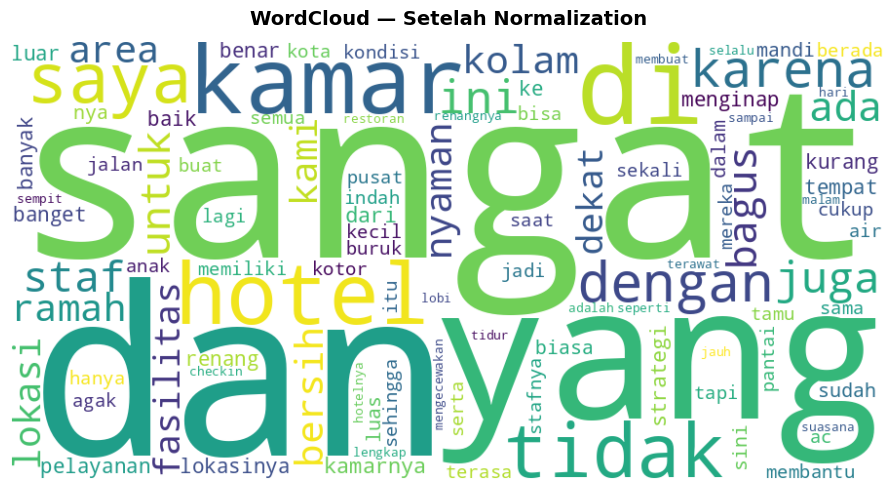

In [ ]:
tampil_wordcloud(
    df['review_normalized'],
    'WordCloud — Setelah Normalization',
    simpan_path=OUTPUT_DIR + 'wc_03_normalization.png'
)

## 9. Stopword Removal

Dilakukan dalam **2 tahap**:
- **Tahap 1:** Stopword Sastrawi dasar (dengan pengecualian kata penting) → cek frekuensi kata hasil
- **Tahap 2:** Tambah custom stopword berdasarkan hasil cek manual di Tahap 1

**Kata yang WAJIB dipertahankan (tidak boleh masuk stopword):**
- Negasi: `tidak, tak, bukan, jangan, belum, tanpa, tiada`
- Intensitas: `sangat, banget, sekali, lebih, cukup, terlalu, paling, agak, kurang, amat`

In [ ]:
from Sastrawi.StopWordRemover.StopWordRemoverFactory import StopWordRemoverFactory

sw_factory = StopWordRemoverFactory()
stopwords  = set(sw_factory.get_stop_words())

# Menampilkan semua stopword Sastrawi diurutkan alfabetis
sw_list = sorted(stopwords)
print(f"Total stopword Sastrawi: {len(sw_list)} kata\n")
print(sw_list)

Total stopword Sastrawi: 809 kata

['a', 'ada', 'adalah', 'adanya', 'adapun', 'agak', 'agaknya', 'agar', 'akan', 'akankah', 'akhir', 'akhiri', 'akhirnya', 'aku', 'akulah', 'amat', 'amatlah', 'anda', 'andalah', 'antar', 'antara', 'antaranya', 'apa', 'apaan', 'apabila', 'apakah', 'apalagi', 'apatah', 'arti', 'artinya', 'asal', 'asalkan', 'atas', 'atau', 'ataukah', 'ataupun', 'awal', 'awalnya', 'b', 'bagai', 'bagaikan', 'bagaimana', 'bagaimanakah', 'bagaimanapun', 'bagainamakah', 'bagi', 'bagian', 'bahkan', 'bahwa', 'bahwasannya', 'bahwasanya', 'baik', 'baiklah', 'bakal', 'bakalan', 'balik', 'banyak', 'bapak', 'baru', 'bawah', 'beberapa', 'begini', 'beginian', 'beginikah', 'beginilah', 'begitu', 'begitukah', 'begitulah', 'begitupun', 'bekerja', 'belakang', 'belakangan', 'belum', 'belumlah', 'benar', 'benarkah', 'benarlah', 'berada', 'berakhir', 'berakhirlah', 'berakhirnya', 'berapa', 'berapakah', 'berapalah', 'berapapun', 'berarti', 'berawal', 'berbagai', 'berdatangan', 'beri', 'berikan',

In [ ]:
# Inisialisasi stopword Sastrawi
sw_factory = StopWordRemoverFactory()
stopwords  = set(sw_factory.get_stop_words())

# Kata yang WAJIB dipertahankan — dikecualikan dari stopword removal
kata_wajib_pertahankan = {
    # Negasi — membalik makna sentimen jika dihapus
    'tidak', 'tak', 'bukan', 'bukanlah', 'bukannya', 'bukankah',
    'belum', 'jangan', 'jangankan', 'tanpa',

    # Intensitas — menentukan kuat/lemahnya sentimen
    'sangat', 'amat', 'amatlah', 'sangatlah',
    'lebih', 'paling', 'kurang', 'cukup', 'terlalu',
    'agak', 'sekali', 'berlebihan', 'keterlaluan',
    'sedikit', 'sedikitnya', 'hampir', 'nyaris', 'luar', 'biasa', 'banyak',

    # Kontras & ekspektasi — penting untuk arah sentimen
    'padahal', 'namun', 'tetapi', 'tapi',
    'meski', 'meskipun', 'walau', 'walaupun',
    'malah', 'malahan', 'justru', 'bahkan', 'sebaliknya',

    # Kondisi & kepastian — nuansa sentimen
    'memang', 'ternyata', 'sebenarnya', 'sebetulnya',
    'seharusnya', 'masih', 'sudah', 'pernah',
    'selalu', 'sering', 'sempat',

    # Aspek Room
    'besar', 'kecil', 'enak',

    # Aspek Location
    'dekat', 'jauh', 'tepat', 'berada', 'sekitarnya', 'belakang', 'depan', 'tempat',

    # Aspek Service
    'lama',

    # Kata penting konteks hotel
    'baik', 'benar', 'jelas', 'pantas', 'percuma',
    'penting', 'pasti', 'kembali', 'perlu',
    'mau', 'bisa', 'dapat', 'terasa', 'terlihat',
}

# Mempertahankan yang memang ada di stopword Sastrawi (kata yang tidak ada di stopword tidak perlu dipertahankan)
kata_dikecualikan = stopwords & kata_wajib_pertahankan

# Stopword tahap 1 = Stopword Sastrawi dikurangi kata yang wajib pertahankan
stopwords_tahap1 = stopwords - kata_wajib_pertahankan

print(f"Stopword Sastrawi asli        : {len(stopwords)} kata")
print(f"Stopword setelah pengecualian : {len(stopwords_tahap1)} kata")
print(f"Kata yang berhasil dipertahankan: {len(kata_dikecualikan)} kata")
print(f"\nKata dikecualikan (ada di Sastrawi & dipertahankan):")
print(f"  {sorted(kata_dikecualikan)}")

Stopword Sastrawi asli        : 809 kata
Stopword setelah pengecualian : 729 kata
Kata yang berhasil dipertahankan: 80 kata

Kata dikecualikan (ada di Sastrawi & dipertahankan):
  ['agak', 'amat', 'amatlah', 'bahkan', 'baik', 'banyak', 'belakang', 'belum', 'benar', 'berada', 'berlebihan', 'besar', 'biasa', 'bisa', 'bukan', 'bukankah', 'bukanlah', 'bukannya', 'cukup', 'dapat', 'dekat', 'depan', 'enak', 'hampir', 'jangan', 'jangankan', 'jauh', 'jelas', 'justru', 'kecil', 'kembali', 'keterlaluan', 'kurang', 'lama', 'lebih', 'luar', 'malah', 'malahan', 'masih', 'mau', 'memang', 'meski', 'meskipun', 'namun', 'nyaris', 'padahal', 'paling', 'pantas', 'pasti', 'penting', 'percuma', 'perlu', 'pernah', 'sangat', 'sangatlah', 'sebaliknya', 'sebenarnya', 'sebetulnya', 'sedikit', 'sedikitnya', 'seharusnya', 'sekali', 'sekitarnya', 'selalu', 'sempat', 'sering', 'sudah', 'tak', 'tanpa', 'tapi', 'tempat', 'tepat', 'terasa', 'terlalu', 'terlihat', 'ternyata', 'tetapi', 'tidak', 'walau', 'walaupun']


### 9a. Stopword Removal Tahap 1

In [ ]:
def remove_stopwords(text, sw_set):
    """Hapus token yang ada di sw_set."""
    if not isinstance(text, str) or text.strip() == '':
        return ''
    tokens = [t for t in text.split() if t not in sw_set]
    return ' '.join(tokens)

print("Menjalankan stopword removal tahap 1...")
df['review_sw_tahap1'] = df['review_normalized'].progress_apply(
    lambda t: remove_stopwords(t, stopwords_tahap1)
)

tampil_contoh(df, 'review_normalized', 'review_sw_tahap1', 'Stopword Removal Tahap 1', n=15)

Menjalankan stopword removal tahap 1...


100%|██████████| 7821/7821 [00:00<00:00, 112132.75it/s]


Contoh Hasil: Stopword Removal Tahap 1
  (7801 ulasan mengalami perubahan dari 7821 total)



,Sebelum (review_normalized),Sesudah (review_sw_tahap1)
#1,pertama kali di sini super kagum sama interior hotel authentic banget kamarnya nyaman dan televisi nya besar banget,super kagum interior hotel authentic banget kamarnya nyaman televisi besar banget
#2,pelayanan oke banget dibantu dengan resepsionis yang sangat ramah sekali pelayanan memuaskan,pelayanan oke banget dibantu resepsionis sangat ramah sekali pelayanan memuaskan
#3,kolam renang dan gym nya sangat bagus dan yang terbaik dari hotel lain,kolam renang gym sangat bagus terbaik hotel
#4,kami sekeluarga senang kamarnya bersih dan nyaman area taman nya sangat rapi dan indah kolam renang juga bagus,sekeluarga senang kamarnya bersih nyaman area taman sangat rapi indah kolam renang bagus
#5,perbotan kamar seperti ac dan dispenser air minum sering kali tidak berfungsi sangat mengganggu kenyamanan,perbotan kamar ac dispenser air minum sering tidak berfungsi sangat mengganggu kenyamanan
#6,dekorasinya sangat bagus tentang sejarah apalagi ada lukisan bersejarah,dekorasinya sangat bagus sejarah lukisan bersejarah
#7,staf sangat ramah dan mengajak kami berkeliling hotel menceritakan sejarah dan membantu mengambil foto,staf sangat ramah mengajak berkeliling hotel menceritakan sejarah membantu mengambil foto
#8,staf didominasi oleh anak magang mengakibatkan pelayanan jadi tidak konsisten dan tidak profesional,staf didominasi anak magang mengakibatkan pelayanan tidak konsisten tidak profesional
#9,pelayanannya top dan pegawainya ramah sekali,pelayanannya top pegawainya ramah sekali
#10,pelayanan buruk saya dibiarkan menurunkan barang dari mobil sendiri padahal ada staf yang melihat,pelayanan buruk dibiarkan menurunkan barang mobil padahal staf


In [ ]:
# Cek frekuensi kata setelah tahap 1
df_freq_tahap1 = top_kata(df['review_sw_tahap1'], n=400, judul='setelah stopword Tahap 1')
print(df_freq_tahap1.to_string(index=False))


Top 400 kata — setelah stopword Tahap 1:
            Kata  Frekuensi
          sangat       8693
           kamar       3953
           hotel       3597
           tidak       3406
            staf       1679
           bagus       1575
           kolam       1416
          bersih       1411
           ramah       1348
            area       1346
          nyaman       1326
          lokasi       1228
       fasilitas       1163
           dekat       1145
        kamarnya       1135
       strategis       1053
          tempat        989
          renang        975
          banget        972
       pelayanan        957
        menginap        938
       lokasinya        915
           benar        885
          banyak        840
            luar        815
            baik        790
          kurang        788
           biasa        748
           mandi        721
           sudah        706
            luas        703
           jalan        603
           cukup        600
      

WordCloud disimpan: /content/drive/MyDrive/SKRIPSI_NAVY/Dataset/Dataset_Persiapan/Dataset_Text_Preprocessing/wc_04_stopword_tahap1.png


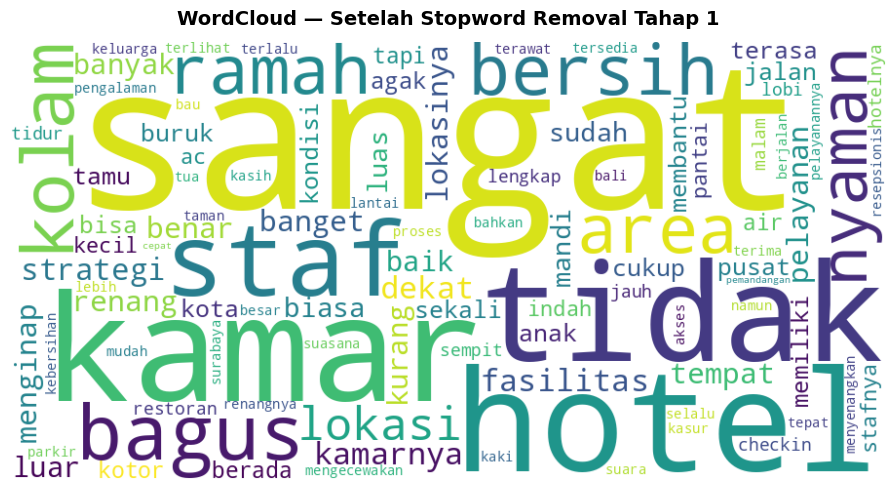

In [ ]:
tampil_wordcloud(
    df['review_sw_tahap1'],
    'WordCloud — Setelah Stopword Removal Tahap 1',
    warna='YlOrRd',
    simpan_path=OUTPUT_DIR + 'wc_04_stopword_tahap1.png'
)

### 9b. Review Manual & Tambah Custom Stopword (Tahap 2)

Berdasarkan frekuensi kata di atas, perlu ditambahkan kata-kata yang masih dianggap tidak informatif untuk sentimen ke dalam `custom_stopwords_tambahan`

**Kata yang ditambahkan ke stopword:**
- Kata umum yang tidak membawa sentimen
- Kata yang terlalu umum di domain hotel sehingga tidak diskriminatif

**Kata yang jangan ditambahkan:**
- Semua kata negasi dan intensitas (sudah aman dari tahap 1)
- Kata yang memiliki konotasi sentimen (`bersih`, `kotor`, `nyaman`, `lambat`, dst.)

In [ ]:
# Menambahkan kata yang tidak informatif untuk sentimen
custom_stopwords_tambahan = {
    'juga', 'sih', 'deh', 'lho', 'nih', 'lah', 'kan', 'wow',
    'nya', 'kok', 'lah', 'dong', 'oh'
}
# Menggabungkan stopword final
stopwords_final = stopwords_tahap1 | custom_stopwords_tambahan
print(f"Stopword final: {len(stopwords_final)} kata")

Stopword final: 735 kata


In [ ]:
print("Menjalankan stopword removal tahap 2 (final)...")
df['review_stopword_removed'] = df['review_normalized'].progress_apply(
    lambda t: remove_stopwords(t, stopwords_final)
)

tampil_contoh(df, 'review_sw_tahap1', 'review_stopword_removed', 'Stopword Removal Tahap 2 (Final)', n=10)

Menjalankan stopword removal tahap 2 (final)...


100%|██████████| 7821/7821 [00:00<00:00, 172681.70it/s]


Contoh Hasil: Stopword Removal Tahap 2 (Final)
  (142 ulasan mengalami perubahan dari 7821 total)



,Sebelum (review_sw_tahap1),Sesudah (review_stopword_removed)
#1,lokasinya bagus deh kemana sangat dekat oh staffnya sangat ramah profesional,lokasinya bagus kemana sangat dekat staffnya sangat ramah profesional
#2,lokasinya mantap bisa nih keliling tunjungan banyak caf terkenal,lokasinya mantap bisa keliling tunjungan banyak caf terkenal
#3,cukup kasur empuk kamar bersih rapi perlengkapan lengkap kesini deh,cukup kasur empuk kamar bersih rapi perlengkapan lengkap kesini
#4,kamarnya bersih tidak apek tempat tidurnya empuk kebersihan sih bikin betah rebahan staffnya ramah staf namanya yumi super helpful selalu senyum,kamarnya bersih tidak apek tempat tidurnya empuk kebersihan bikin betah rebahan staffnya ramah staf namanya yumi super helpful selalu senyum
#5,proses checkin cepat tidak ribet staffnya super helpful kamar bersih fresh super nyaman chil sih highly recommend arcadia,proses checkin cepat tidak ribet staffnya super helpful kamar bersih fresh super nyaman chil highly recommend arcadia
#6,hotel nuansa klasik seru banget kamarnya bersih pokoknya nyaman deh,hotel nuansa klasik seru banget kamarnya bersih pokoknya nyaman
#7,ternyata kamarnya luas bersih next surabaya deh,ternyata kamarnya luas bersih next surabaya
#8,kamar hotel kotor televisi buram shower head banyak water mark ac tidak berfungsi soap dispenser sudah tidak layak kamar tidak layak tempati parah...,kamar hotel kotor televisi buram shower head banyak water mark ac tidak berfungsi soap dispenser sudah tidak layak kamar tidak layak tempati parah
#9,lokasi bagus dekat tunjungan plaza sarapan sih oke tapi kamar tidak kesetnya air kamar mandi mati stopkontak meja longgar susah charging handphone,lokasi bagus dekat tunjungan plaza sarapan oke tapi kamar tidak kesetnya air kamar mandi mati stopkontak meja longgar susah charging handphone
#10,kamar selalu bersih lokasinya strategis banget dekat tempat selalu sih surabaya,kamar selalu bersih lokasinya strategis banget dekat tempat selalu surabaya


In [ ]:
# Verifikasi kata negasi & intensitas masih ada
print("Verifikasi kata penting masih ada setelah stopword removal:")
for kata in ['tidak', 'kurang', 'bukan', 'jangan', 'sangat', 'banget', 'terlalu', 'cukup']:
    n = df['review_stopword_removed'].str.contains(r'\b' + kata + r'\b', na=False).sum()
    status = 'OK' if n > 0 else 'HILANG!'
    print(f"  [{status}] '{kata}' muncul di {n} ulasan")

Verifikasi kata penting masih ada setelah stopword removal:
  [OK] 'tidak' muncul di 2454 ulasan
  [OK] 'kurang' muncul di 719 ulasan
  [OK] 'bukan' muncul di 43 ulasan
  [OK] 'jangan' muncul di 17 ulasan
  [OK] 'sangat' muncul di 5119 ulasan
  [OK] 'banget' muncul di 827 ulasan
  [OK] 'terlalu' muncul di 261 ulasan
  [OK] 'cukup' muncul di 545 ulasan


WordCloud disimpan: /content/drive/MyDrive/SKRIPSI_NAVY/Dataset/Dataset_Persiapan/Dataset_Text_Preprocessing/wc_05_stopword_final.png


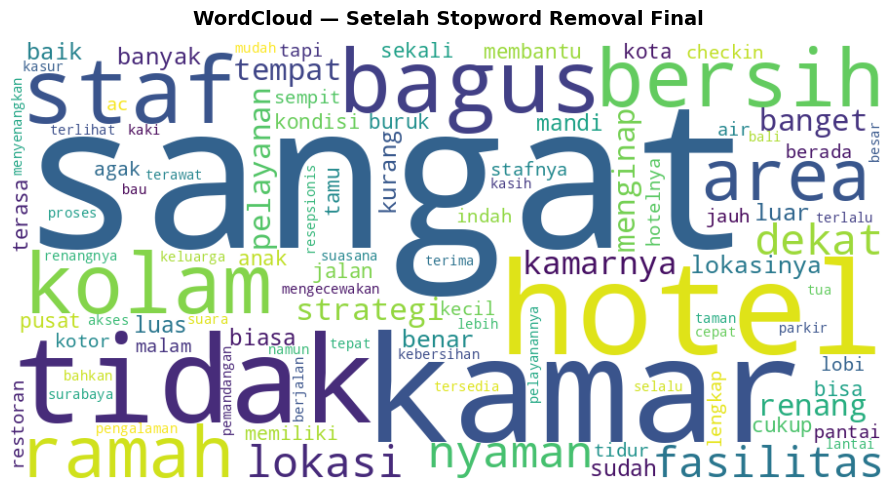

In [ ]:
tampil_wordcloud(
    df['review_stopword_removed'],
    'WordCloud — Setelah Stopword Removal Final',
    simpan_path=OUTPUT_DIR + 'wc_05_stopword_final.png'
)

## 10. Stemming

Mengembalikan kata ke bentuk dasarnya menggunakan **PySastrawi**.

Tahap ini menghasilkan **dua kolom final** untuk skenario model:
- `review_non_stemmed` — teks setelah stopword removal, tanpa stemming
- `review_stemmed` — teks setelah stopword removal, dengan stemming

In [ ]:
stemmer_factory = StemmerFactory()
stemmer         = stemmer_factory.create_stemmer()

# Cek contoh stemming kata domain hotel
print("Contoh pengaruh stemming pada kata domain hotel:")
kata_uji = [
    'membersihkan', 'kebersihan', 'kenyamanan', 'pelayanannya',
    'menginap', 'dipesankan', 'strategis', 'menyenangkan',
    'tidak', 'kurang', 'sangat'
]
for kata in kata_uji:
    print(f"  {kata:20s} -> {stemmer.stem(kata)}")

Contoh pengaruh stemming pada kata domain hotel:
  membersihkan         -> bersih
  kebersihan           -> bersih
  kenyamanan           -> nyaman
  pelayanannya         -> layan
  menginap             -> inap
  dipesankan           -> pesan
  strategis            -> strategis
  menyenangkan         -> senang
  tidak                -> tidak
  kurang               -> kurang
  sangat               -> sangat


In [ ]:
def stem_text(text):
    if not isinstance(text, str) or text.strip() == '':
        return ''
    tokens = [stemmer.stem(t) for t in text.split()]
    return ' '.join(tokens)

# Non-stemmed = langsung dari stopword removal
df['review_non_stemmed'] = df['review_stopword_removed']

# Stemmed
print("Menjalankan proses stemming...")
df['review_stemmed'] = df['review_stopword_removed'].progress_apply(stem_text)

tampil_contoh(df, 'review_non_stemmed', 'review_stemmed', 'Stemming', n=10)

Menjalankan proses stemming...


100%|██████████| 7821/7821 [00:01<00:00, 5733.44it/s]


Contoh Hasil: Stemming
  (7605 ulasan mengalami perubahan dari 7821 total)



,Sebelum (review_non_stemmed),Sesudah (review_stemmed)
#1,super kagum interior hotel authentic banget kamarnya nyaman televisi besar banget,super kagum interior hotel authentic banget kamar nyaman televisi besar banget
#2,pelayanan oke banget dibantu resepsionis sangat ramah sekali pelayanan memuaskan,layan oke banget bantu resepsionis sangat ramah sekali layan muas
#3,kolam renang gym sangat bagus terbaik hotel,kolam renang gym sangat bagus baik hotel
#4,sekeluarga senang kamarnya bersih nyaman area taman sangat rapi indah kolam renang bagus,keluarga senang kamar bersih nyaman area taman sangat rapi indah kolam renang bagus
#5,perbotan kamar ac dispenser air minum sering tidak berfungsi sangat mengganggu kenyamanan,bot kamar ac dispenser air minum sering tidak fungsi sangat ganggu nyaman
#6,dekorasinya sangat bagus sejarah lukisan bersejarah,dekorasi sangat bagus sejarah lukis sejarah
#7,staf sangat ramah mengajak berkeliling hotel menceritakan sejarah membantu mengambil foto,staf sangat ramah ajak keliling hotel cerita sejarah bantu ambil foto
#8,staf didominasi anak magang mengakibatkan pelayanan tidak konsisten tidak profesional,staf dominasi anak magang akibat layan tidak konsisten tidak profesional
#9,pelayanannya top pegawainya ramah sekali,layan top pegawai ramah sekali
#10,pelayanan buruk dibiarkan menurunkan barang mobil padahal staf,layan buruk biar turun barang mobil padahal staf


WordCloud disimpan: /content/drive/MyDrive/SKRIPSI_NAVY/Dataset/Dataset_Persiapan/Dataset_Text_Preprocessing/wc_06_non_stemmed.png


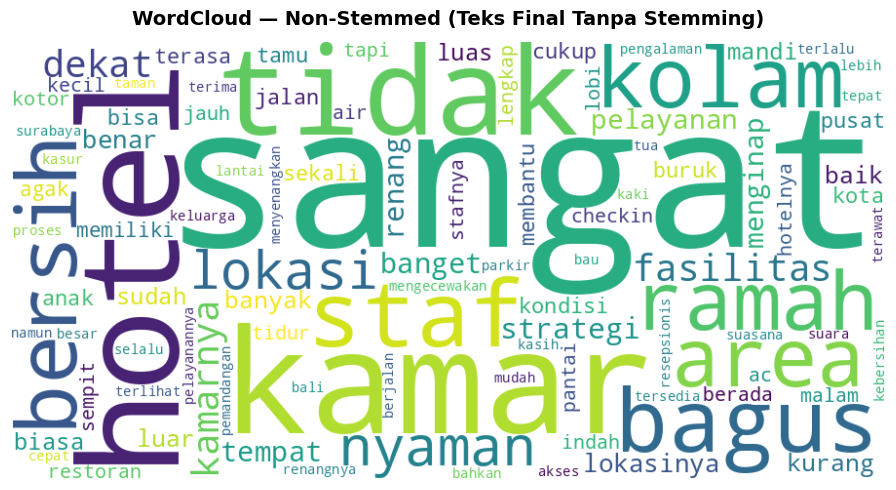

WordCloud disimpan: /content/drive/MyDrive/SKRIPSI_NAVY/Dataset/Dataset_Persiapan/Dataset_Text_Preprocessing/wc_07_stemmed.png


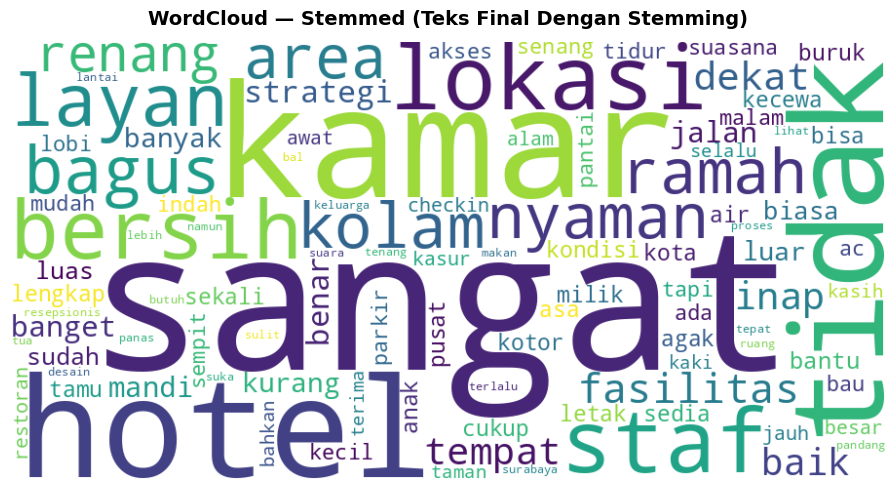

In [ ]:
tampil_wordcloud(
    df['review_non_stemmed'],
    'WordCloud — Non-Stemmed (Teks Final Tanpa Stemming)',
    simpan_path=OUTPUT_DIR + 'wc_06_non_stemmed.png'
)

tampil_wordcloud(
    df['review_stemmed'],
    'WordCloud — Stemmed (Teks Final Dengan Stemming)',
    simpan_path=OUTPUT_DIR + 'wc_07_stemmed.png'
)

## 11. Ringkasan & Eksplorasi Akhir

In [ ]:
# Statistik panjang teks tiap tahap
stages = {
    'Teks Asli'      : TEXT_COL,
    'After Cleaning' : 'review_clean',
    'After Normalize': 'review_normalized',
    'After Stopword' : 'review_stopword_removed',
    'Non-Stemmed'    : 'review_non_stemmed',
    'Stemmed'        : 'review_stemmed',
}

print("Statistik panjang teks (jumlah token) per tahap:")
rows = []
for label, col in stages.items():
    lengths = df[col].dropna().apply(lambda x: len(str(x).split()))
    rows.append({'Tahap': label, 'Min': int(lengths.min()),
                 'Max': int(lengths.max()), 'Mean': round(lengths.mean(), 1),
                 'Median': int(lengths.median())})
print(pd.DataFrame(rows).to_string(index=False))

Statistik panjang teks (jumlah token) per tahap:
          Tahap  Min  Max  Mean  Median
      Teks Asli    4  105  24.2      23
 After Cleaning    4  109  24.4      23
After Normalize    4  109  24.4      23
 After Stopword    3   65  16.5      16
    Non-Stemmed    3   65  16.5      16
        Stemmed    3   65  16.5      16


In [ ]:
# Cek ulasan yang tersisa <= 5 kata setelah preprocessing
mask_pendek = df['review_non_stemmed'].apply(lambda x: len(str(x).split())) <= 5

df_pendek = df[mask_pendek][['id', TEXT_COL, 'review_non_stemmed', 'review_stemmed'] + LABEL_COLS].copy()

print(f"Jumlah ulasan dengan <= 3 kata: {len(df_pendek)}")
print(f"Persentase dari total         : {len(df_pendek)/len(df)*100:.2f}%\n")
pd.set_option('display.max_colwidth', 300)
display(df_pendek)

Jumlah ulasan dengan <= 3 kata: 19
Persentase dari total         : 0.24%



,id,review_text_translated,review_non_stemmed,review_stemmed,Room,Hotel,Location,Service
8,9,pelayanannya top dan pegawainya ramah sekali,pelayanannya top pegawainya ramah sekali,layan top pegawai ramah sekali,None,None,None,Positive
2817,2818,"tempatnya yang strategis, hanya beberapa langkah ke tempat wisata.",tempatnya strategis langkah tempat wisata,tempat strategis langkah tempat wisata,None,None,Positive,None
2842,2843,Fasilitas spa yang tersedia sangat komplit.,fasilitas spa tersedia sangat komplit,fasilitas spa sedia sangat komplit,None,Positive,None,None
2877,2878,Beberapa karyawan tidak Sopan & mereka juga Rasis,karyawan tidak sopan racist,karyawan tidak sopan racist,None,None,None,Negative
2930,2931,Kamarnya cukup bagus dan pelayanannya ramah.,kamarnya cukup bagus pelayanannya ramah,kamar cukup bagus layan ramah,Positive,None,None,Positive
3493,3494,"Menginap di kamar 521, Kamar bersih dan menyenangkan",menginap kamar kamar bersih menyenangkan,inap kamar kamar bersih senang,Positive,None,None,None
3550,3551,Hotel yang bagus dan bersih dengan lokasi strategis.,hotel bagus bersih lokasi strategis,hotel bagus bersih lokasi strategis,None,Positive,Positive,None
3595,3596,"Punya ballroom yang sangat nyaman,luas,dan bagus.",ballroom sangat nyaman luas bagus,ballroom sangat nyaman luas bagus,None,Positive,None,None
3597,3598,Setiap ke hotel ini pasti saja diberikan pelayanan yang sangat memuaskan.,hotel pasti pelayanan sangat memuaskan,hotel pasti layan sangat muas,None,None,None,Positive
3620,3621,"Pelayanan dan stafnya keren²,,,❤️",pelayanan stafnya keren,layan staf keren,None,None,None,Positive


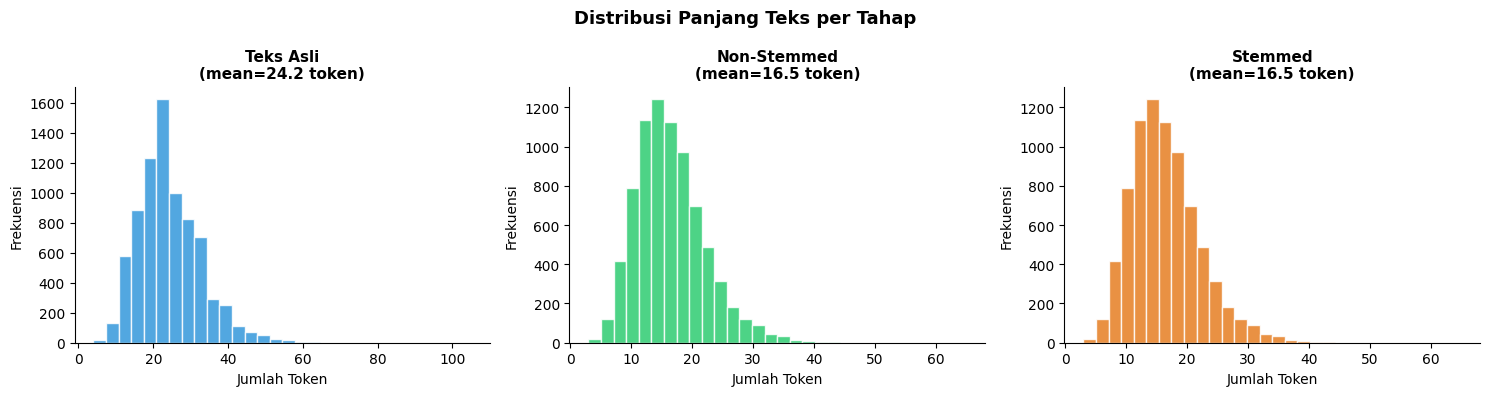

In [ ]:
# Visualisasi distribusi panjang teks
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
plot_stages = [
    ('Teks Asli',   TEXT_COL,              '#3498db'),
    ('Non-Stemmed', 'review_non_stemmed',  '#2ecc71'),
    ('Stemmed',     'review_stemmed',      '#e67e22'),
]
for ax, (label, col, color) in zip(axes, plot_stages):
    lengths = df[col].dropna().apply(lambda x: len(str(x).split()))
    ax.hist(lengths, bins=30, color=color, edgecolor='white', alpha=0.85)
    ax.set_title(f'{label}\n(mean={lengths.mean():.1f} token)', fontsize=11, fontweight='bold')
    ax.set_xlabel('Jumlah Token')
    ax.set_ylabel('Frekuensi')
    ax.spines[['top','right']].set_visible(False)
plt.suptitle('Distribusi Panjang Teks per Tahap', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig(OUTPUT_DIR + 'distribusi_panjang_teks.png', dpi=150, bbox_inches='tight')
plt.show()

In [ ]:
# Ukuran vocabulary
print("Ukuran vocabulary:")
for label, col in [('Non-Stemmed', 'review_non_stemmed'), ('Stemmed', 'review_stemmed')]:
    semua = ' '.join(df[col].dropna().astype(str)).split()
    print(f"  {label:15s}: {len(set(semua)):,} kata unik, {len(semua):,} total token")

Ukuran vocabulary:
  Non-Stemmed    : 5,820 kata unik, 129,175 total token
  Stemmed        : 3,983 kata unik, 129,175 total token


In [ ]:
# ============================================================
# CEK KUALITAS DATASET SETELAH TEXT PREPROCESSING
# ============================================================

print("=" * 60)
print("   CEK KUALITAS DATASET SETELAH TEXT PREPROCESSING")
print("=" * 60)

kolom_cek = ['review_non_stemmed', 'review_stemmed']

for col in kolom_cek:
    print(f"\n--- Kolom: {col} ---")

    # 1. Missing value
    n_null = df[col].isna().sum()
    print(f"  Missing value (NaN)     : {n_null}")

    # 2. String kosong
    n_kosong = (df[col].astype(str).str.strip() == '').sum()
    print(f"  String kosong ('')      : {n_kosong}")

    # 3. Terlalu pendek (1 kata atau kurang) — kemungkinan tidak informatif
    n_pendek = (df[col].astype(str).str.split().apply(len) <= 1).sum()
    print(f"  Teks <= 1 kata          : {n_pendek}")

    # 4. Gabungan (kosong atau sangat pendek)
    mask_bermasalah = (
        df[col].isna() |
        (df[col].astype(str).str.strip() == '') |
        (df[col].astype(str).str.split().apply(len) <= 1)
    )
    print(f"  Total bermasalah        : {mask_bermasalah.sum()}")


# ============================================================
# Tampilkan baris yang bermasalah di review_non_stemmed
# ============================================================
mask_final = (
    df['review_non_stemmed'].isna() |
    (df['review_non_stemmed'].astype(str).str.strip() == '') |
    (df['review_non_stemmed'].astype(str).str.split().apply(len) <= 1)
)

df_bermasalah = df[mask_final][['id', TEXT_COL, 'review_non_stemmed', 'review_stemmed'] + LABEL_COLS]

print(f"\n\nTotal baris bermasalah: {len(df_bermasalah)}")

if len(df_bermasalah) > 0:
    print("\nPreview baris bermasalah:")
    print(df_bermasalah.head(20).to_string(index=False))

    # Hapus baris bermasalah dari dataset
    df_clean = df[~mask_final].copy()
    print(f"\nDataset sebelum hapus : {len(df):,} baris")
    print(f"Dataset setelah hapus : {len(df_clean):,} baris")
    print(f"Baris dihapus         : {len(df) - len(df_clean)}")

    # Update df dan simpan ulang
    df = df_clean.copy()
    df.to_excel(OUTPUT_FILE, index=False)

    # Update juga CSV modeling
    kolom_modeling = ['id', TEXT_COL, 'review_non_stemmed', 'review_stemmed'] + LABEL_COLS
    kolom_modeling = [c for c in kolom_modeling if c in df.columns]
    df[kolom_modeling].to_csv(OUTPUT_DIR + 'dataset_for_modeling.csv',
                               index=False, encoding='utf-8-sig')
    print("\nDataset sudah diperbarui dan disimpan ulang.")
else:
    print("\nSemua baris valid. Tidak ada yang perlu dihapus.")

print(f"\nDataset final: {len(df):,} baris")

   CEK KUALITAS DATASET SETELAH TEXT PREPROCESSING

--- Kolom: review_non_stemmed ---
  Missing value (NaN)     : 0
  String kosong ('')      : 0
  Teks <= 1 kata          : 0
  Total bermasalah        : 0

--- Kolom: review_stemmed ---
  Missing value (NaN)     : 0
  String kosong ('')      : 0
  Teks <= 1 kata          : 0
  Total bermasalah        : 0


Total baris bermasalah: 0

Semua baris valid. Tidak ada yang perlu dihapus.

Dataset final: 7,821 baris


## 12. Export Dataset

In [ ]:
# Simpan dataset lengkap (semua kolom tahapan)
df.to_excel(OUTPUT_FILE, index=False)
print(f"Dataset lengkap disimpan: {OUTPUT_FILE}")
print(f"Shape: {df.shape}")

Dataset lengkap disimpan: /content/drive/MyDrive/SKRIPSI_NAVY/Dataset/Dataset_Persiapan/Dataset_Text_Preprocessing/hotel_reviews_preprocessed.xlsx
Shape: (7821, 24)


In [ ]:
# Simpan versi dataset untuk modeling
kolom_modeling = ['id', TEXT_COL, 'review_non_stemmed', 'review_stemmed'] + LABEL_COLS
kolom_modeling = [c for c in kolom_modeling if c in df.columns]

df_modeling  = df[kolom_modeling].copy()
csv_path     = OUTPUT_DIR + 'dataset_for_modeling.csv'
df_modeling.to_csv(csv_path, index=False, encoding='utf-8-sig')

print(f"Dataset modeling disimpan: {csv_path}")
print(f"Shape: {df_modeling.shape}")
df_modeling.head(3)

Dataset modeling disimpan: /content/drive/MyDrive/SKRIPSI_NAVY/Dataset/Dataset_Persiapan/Dataset_Text_Preprocessing/dataset_for_modeling.csv
Shape: (7821, 8)


,id,review_text_translated,review_non_stemmed,review_stemmed,Room,Hotel,Location,Service
0,1,"Pertama kali disini super kagum sama interior hotel <3\nauthentic banget kamarnya, nyaman dan TV nya besar banget.",super kagum interior hotel authentic banget kamarnya nyaman televisi besar banget,super kagum interior hotel authentic banget kamar nyaman televisi besar banget,Positive,Positive,None,None
1,2,"Pelayanan oke banget dibantu dengan resepsionis yang sangat ramah sekali, pelayanan memuaskan",pelayanan oke banget dibantu resepsionis sangat ramah sekali pelayanan memuaskan,layan oke banget bantu resepsionis sangat ramah sekali layan muas,None,None,None,Positive
2,3,Kolam renang dan gym nya sangat bagus dan yang terbaik dari hotel lain.,kolam renang gym sangat bagus terbaik hotel,kolam renang gym sangat bagus baik hotel,None,Positive,None,None


In [ ]:
print("=" * 62)
print("         RINGKASAN TEXT PREPROCESSING")
print("=" * 62)
print(f"Total data         : {len(df):,} ulasan")
print(f"Input kolom        : {TEXT_COL}")
print()
tahapan = [
    ('1. Text Cleaning',     'URL, HTML, emotikon, angka, tanda baca'),
    ('2. Case Folding',      'Semua huruf → lowercase'),
    ('3. Normalization',     'Frasa hotel + elongasi + kamus alay + custom dict'),
    ('4. Stopword Tahap 1',  'Sastrawi custom (kata negasi & intensitas dipertahankan)'),
    ('5. Stopword Tahap 2',  'Tambah custom stopword berdasarkan review manual'),
    ('6. Non-Stemmed',       'Output: review_non_stemmed'),
    ('7. Stemmed',           'Output: review_stemmed (PySastrawi)'),
]
for tahap, ket in tahapan:
    print(f"  {tahap:28s}: {ket}")
print()
print(f"Output: {OUTPUT_FILE}")
print(f"        {csv_path}")
print("=" * 62)

         RINGKASAN TEXT PREPROCESSING
Total data         : 7,821 ulasan
Input kolom        : review_text_translated

  1. Text Cleaning            : URL, HTML, emotikon, angka, tanda baca
  2. Case Folding             : Semua huruf → lowercase
  3. Normalization            : Frasa hotel + elongasi + kamus alay + custom dict
  4. Stopword Tahap 1         : Sastrawi custom (kata negasi & intensitas dipertahankan)
  5. Stopword Tahap 2         : Tambah custom stopword berdasarkan review manual
  6. Non-Stemmed              : Output: review_non_stemmed
  7. Stemmed                  : Output: review_stemmed (PySastrawi)

Output: /content/drive/MyDrive/SKRIPSI_NAVY/Dataset/Dataset_Persiapan/Dataset_Text_Preprocessing/hotel_reviews_preprocessed.xlsx
        /content/drive/MyDrive/SKRIPSI_NAVY/Dataset/Dataset_Persiapan/Dataset_Text_Preprocessing/dataset_for_modeling.csv
